In [1]:
!pip install -q transformers accelerate pillow kaggle

import os
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_32feae0c86a02acb063a9c9873d0afeb'
!mkdir -p ~/.kaggle
!echo '{"KAGGLE_API_TOKEN":"'$KAGGLE_API_TOKEN'"}' > ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d adityajn105/flickr8k
!unzip -oq flickr8k.zip -d flickr8k_data
print("Dataset ready!")

Dataset URL: https://www.kaggle.com/datasets/adityajn105/flickr8k
License(s): CC0-1.0
100% 1.04G/1.04G [00:51<00:00, 21.8MB/s]

Dataset ready!


In [2]:
import torch
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
import pandas as pd
import random

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base").to(device)

image_folder = "flickr8k_data/Images"
caption_file = "flickr8k_data/captions.txt"
captions_df = pd.read_csv(caption_file)

print("BLIP model loaded — ready to use FINAL BASELINE config (Beam Search, num_beams=5)!")

Using device: cuda


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  990MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

BLIP model loaded — ready to use FINAL BASELINE config (Beam Search, num_beams=5)!


In [3]:
# FINAL BASELINE CONFIGURATION (selected from Day 4 experiments)
FINAL_CONFIG = {
    "num_beams": 5,
    "max_new_tokens": 30
}

def generate_caption(image_path, config=FINAL_CONFIG):
    raw_image = Image.open(image_path).convert("RGB")
    inputs = processor(raw_image, return_tensors="pt").to(device)
    out = model.generate(**inputs, **config)
    caption = processor.decode(out[0], skip_special_tokens=True)
    return caption

print("Final baseline config set: Beam Search, num_beams=5, max_new_tokens=30")

Final baseline config set: Beam Search, num_beams=5, max_new_tokens=30


In [4]:
random.seed(100)  # different seed taake pehle wali images se alag hon (demo variety ke liye)
all_images = os.listdir(image_folder)
demo_images = random.sample(all_images, 6)

print("Demo images selected:")
for img in demo_images:
    print(img)

Demo images selected:
537390477_7dd3407f96.jpg
2171154778_8189169336.jpg
532457586_bddfc5251d.jpg
3628017876_4ac27e687b.jpg
3681056426_fbd6c0c92c.jpg
2328104318_5a43ca170c.jpg


In [5]:
demo_results = {}

for img_name in demo_images:
    img_path = os.path.join(image_folder, img_name)
    caption = generate_caption(img_path)
    human_caps = captions_df[captions_df['image'] == img_name]['caption'].tolist()
    demo_results[img_name] = {
        "blip_caption": caption,
        "human_captions": human_caps
    }
    print(f"\n{img_name}")
    print(f"  BLIP: {caption}")
    print(f"  Human (sample): {human_caps[0]}")


537390477_7dd3407f96.jpg
  BLIP: the dog is black
  Human (sample): A black and a brown dog are fighting .

2171154778_8189169336.jpg
  BLIP: a little boy playing with a bat in a room
  Human (sample): A boy in dark blue clothes is kneeling while holding a toy .

532457586_bddfc5251d.jpg
  BLIP: a man sitting on a bench next to a dog
  Human (sample): A shirtless man with a brown and white dog looking at a woman in jeans and a bikini top who is relaxing on a bench .

3628017876_4ac27e687b.jpg
  BLIP: a little boy playing with a stuffed animal
  Human (sample): A little boy playing with two rubber chickens .

3681056426_fbd6c0c92c.jpg
  BLIP: a clear blue sky
  Human (sample): A professional horse race

2328104318_5a43ca170c.jpg
  BLIP: a man in a blue hoodie using a laptop
  Human (sample): A man in a hoodie is looking at a pad of paper , outside a window .


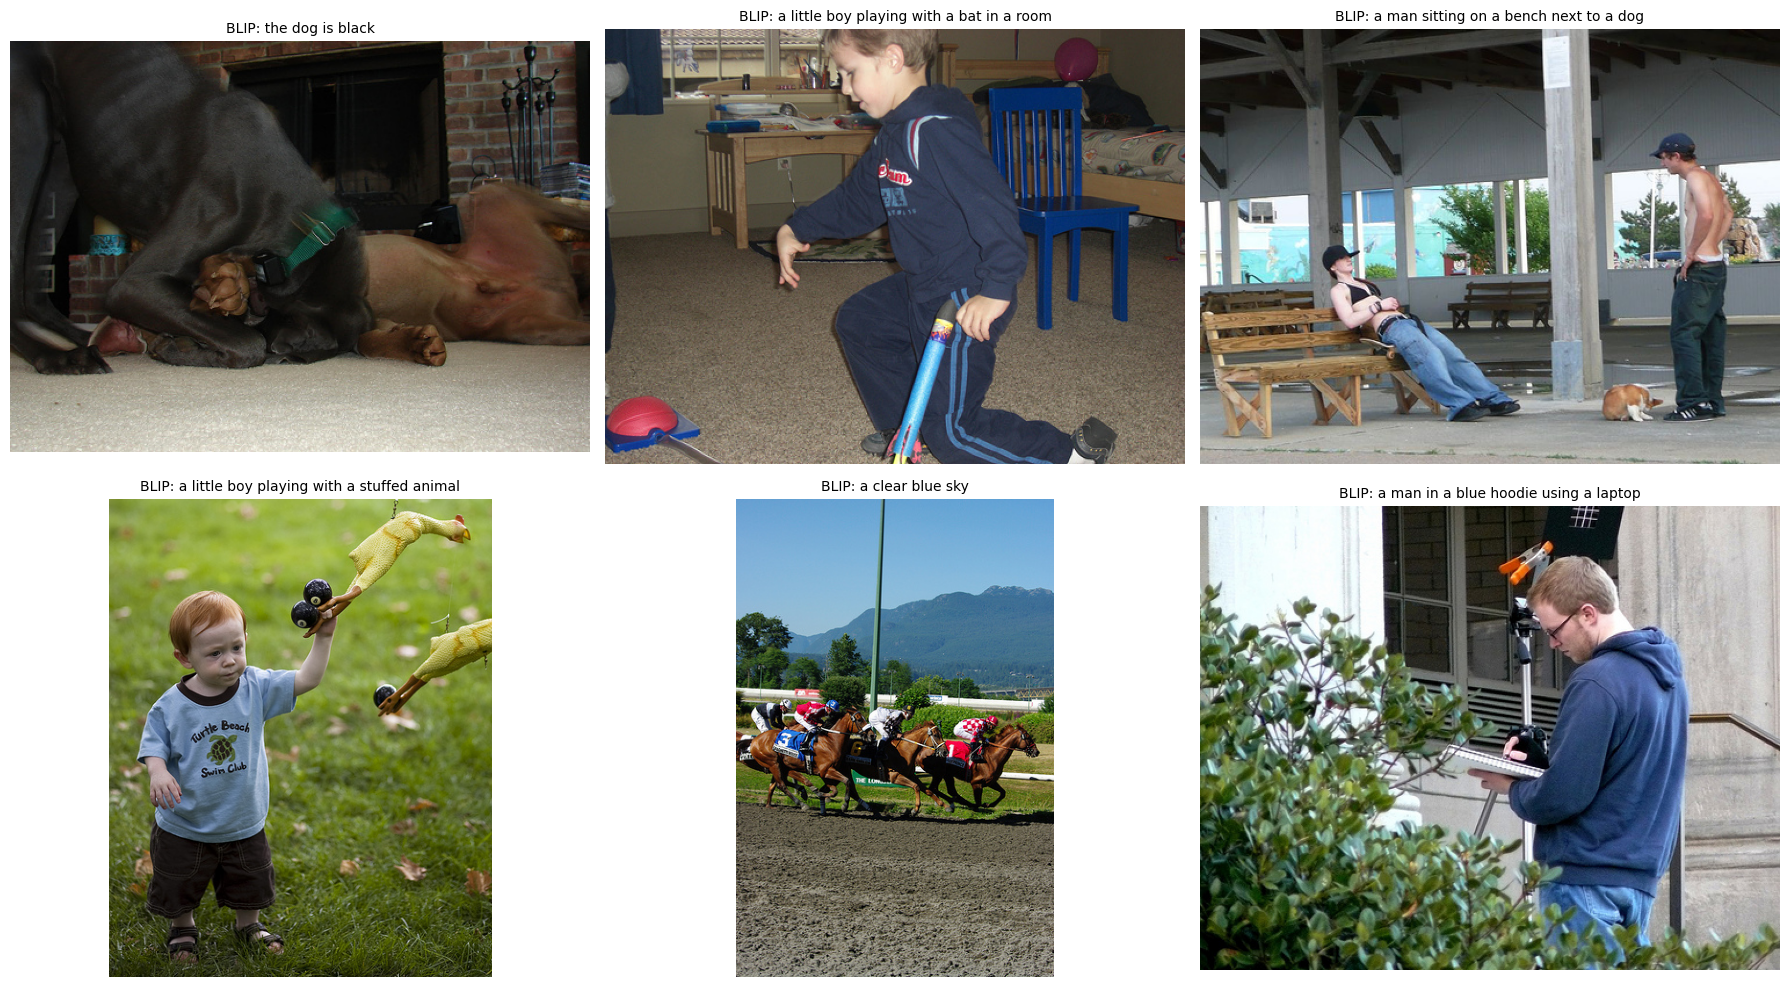

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, img_name in zip(axes, demo_images):
    img_path = os.path.join(image_folder, img_name)
    image = Image.open(img_path).convert("RGB")
    ax.imshow(image)
    blip_cap = demo_results[img_name]["blip_caption"]
    ax.set_title(f"BLIP: {blip_cap}", fontsize=10, wrap=True)
    ax.axis("off")

plt.tight_layout()
plt.savefig("day5_demo_captions.png", dpi=150)
plt.show()

# Week 2 Write-Up: Multimodal Model Development (Baseline)

## 1. Baseline Model Description

**Model:** Salesforce/blip-image-captioning-base (BLIP — Bootstrapping Language-Image Pretraining)

**Architecture Summary:** BLIP combines a Vision Transformer (ViT) image encoder with
a transformer-based text decoder, connected via cross-attention. The image encoder
converts an image into visual embeddings; the text decoder generates captions
word-by-word, attending to relevant image regions at each step.

**Usage Mode:** Zero-shot (no fine-tuning performed) — the pretrained model was used
as-is on the Flickr8k dataset to establish a baseline before any dataset-specific
adaptation.

**Final Baseline Decoding Configuration (selected from Day 4 experiments):**
- Decoding strategy: **Beam Search**
- num_beams: **5**
- max_new_tokens: **30**

## 2. Evaluation Summary (Day 2 Baseline — 200 images, Greedy Decoding)

| Metric   | Score  |
|----------|--------|
| BLEU     | 0.1919 |
| ROUGE-1  | 0.5556 |
| ROUGE-2  | 0.3198 |
| ROUGE-L  | 0.5337 |

## 3. MLflow Run Comparison Summary (Day 4 — 50 images, Config Experiments)

All experiments were tracked in MLflow (experiment: `BLIP_Config_Experiments_Day4`).

| Run | Decoding | Num Beams | Max Tokens | BLEU | ROUGE-1 | ROUGE-2 | ROUGE-L | Avg Time/Image |
|---|---|---|---|---|---|---|---|---|
| Exp1_Greedy_Decoding | Greedy | 1 | 30 | 0.1727 | **0.5626** | **0.3090** | **0.5365** | 0.219s |
| Exp2_BeamSearch | Beam Search | 5 | 30 | **0.2039** | 0.5499 | 0.3014 | 0.5218 | 0.287s |
| Exp3_BeamSearch_Longer | Beam Search | 5 | 50 | 0.2039 | 0.5499 | 0.3014 | 0.5218 | 0.248s |

**Key finding:** Beam search improved BLEU by ~18% relative to greedy decoding, at
the cost of a small drop in ROUGE scores (~2%) and modestly higher inference time.
Increasing `max_new_tokens` beyond 30 had no effect, since BLIP naturally terminates
generation once a caption is complete.

## 4. Chosen Final Baseline

**Decision: Beam Search (num_beams=5, max_new_tokens=30)**

**Justification:** BLEU is generally considered a stronger indicator of overall
caption fluency and precision for this task, and the improvement was consistent
and non-trivial (+18% relative). The ROUGE trade-off was small, and the additional
inference cost (~30% slower per image) is acceptable at this project's scale. This
configuration will be used as the **standard baseline going forward** for any
future fine-tuning comparisons in Week 3+.

## 5. Qualitative Demo Observations (6 Fresh Sample Images)

Using the final baseline configuration, BLIP was tested on 6 new images not seen
in earlier experiments:

- **Strengths observed:** BLIP correctly identified people, common objects (dog,
  laptop, bench), and general activities (playing, sitting) in most images.
- **Weaknesses observed:** On one image showing a horse race, BLIP incorrectly
  described only "a clear blue sky" — completely missing the primary subject. This
  suggests BLIP's zero-shot performance can fail significantly on less common or
  visually complex/dynamic scenes (e.g., motion-heavy sports scenes).
- BLIP captions remain **shorter and more generic** than human captions across the
  board, consistent with earlier findings from Day 2.

## 6. Summary & Next Steps

Over Week 2, a full baseline evaluation pipeline was built for BLIP-based zero-shot
image captioning on Flickr8k: quantitative evaluation (BLEU/ROUGE), MLflow-based
experiment tracking, and a systematic comparison of decoding strategies. The chosen
baseline (Beam Search, num_beams=5) will serve as the reference point for Week 3,
where light fine-tuning (e.g., freezing the vision encoder and training only the
text decoder) will be explored to improve upon these baseline scores — particularly
targeting failure cases like the horse-race example above.